In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# First look at data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Dataset Overview
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (9994, 21)

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Se

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
# Data Cleaning - Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year and Month from Order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

print("Date columns converted successfully!")
print("\nYears in dataset:", sorted(df['Year'].unique()))
print("Order Date dtype:", df['Order Date'].dtype)

Date columns converted successfully!

Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Order Date dtype: datetime64[us]


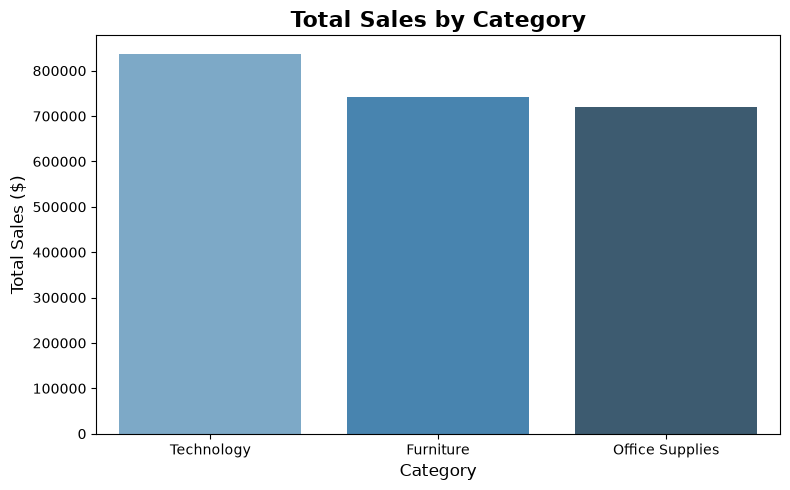

Chart 1 saved!


In [5]:
# Chart 1: Sales by Category
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png', dpi=150)
plt.show()
print("Chart 1 saved!")

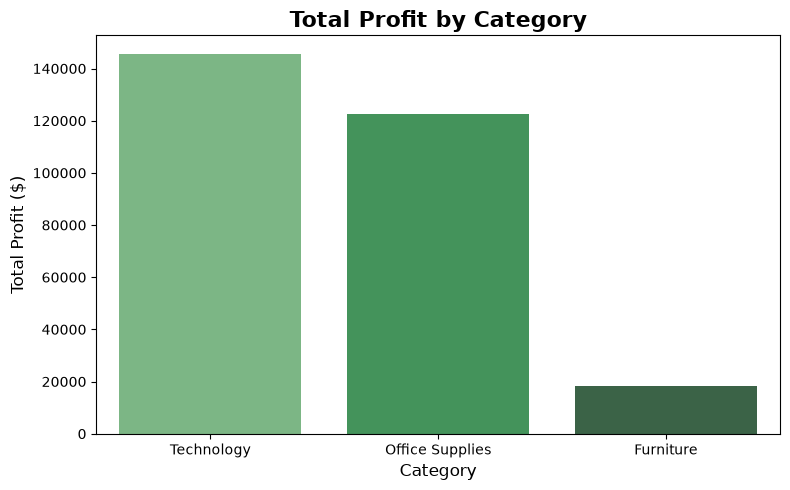

Chart 2 saved!


In [6]:
# Chart 2: Profit by Category
plt.figure(figsize=(8, 5))
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index, y=category_profit.values, palette='Greens_d')
plt.title('Total Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_profit_by_category.png', dpi=150)
plt.show()
print("Chart 2 saved!")

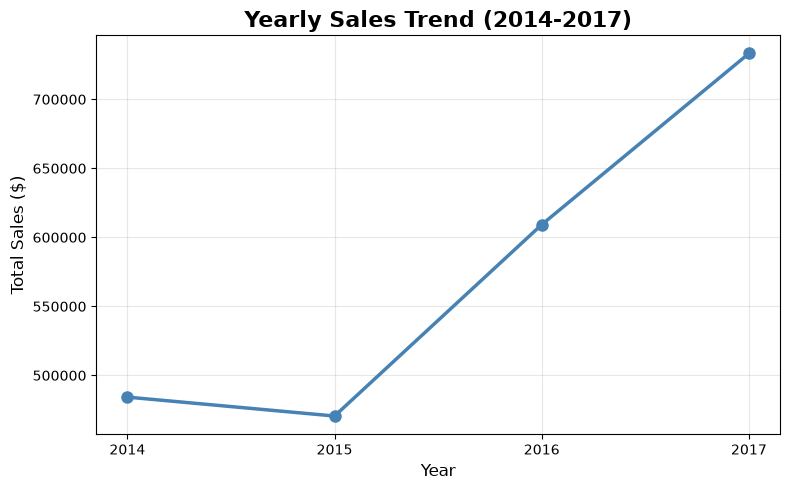

Chart 3 saved!


In [7]:
# Chart 3: yearly Sales Trend
plt.figure(figsize=(8, 5))
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', 
         color='steelblue', linewidth=2.5, markersize=8)
plt.title('Yearly Sales Trend (2014-2017)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks([2014, 2015, 2016, 2017])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_yearly_sales_trend.png', dpi=150)
plt.show()
print("Chart 3 saved!")

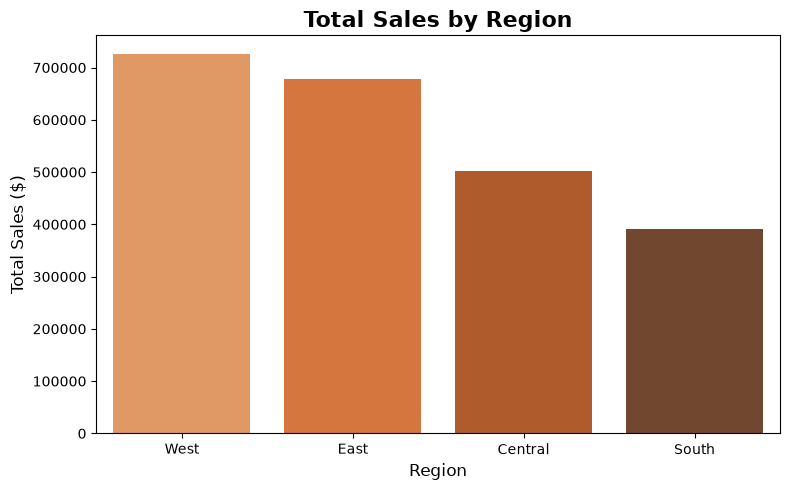

Chart 4 saved!


In [8]:
# Chart 4: Sales by Region
plt.figure(figsize=(8, 5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Oranges_d')
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_sales_by_region.png', dpi=150)
plt.show()
print("Chart 4 saved!")

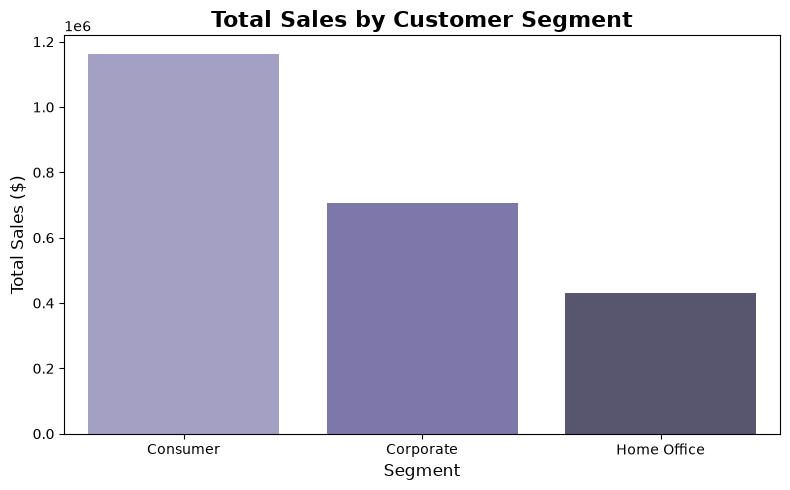

Chart 5 saved!


In [9]:
# Chart 5: Sales by Customer Segment
plt.figure(figsize=(8, 5))
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette='Purples_d')
plt.title('Total Sales by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_sales_by_segment.png', dpi=150)
plt.show()
print("Chart 5 saved!")

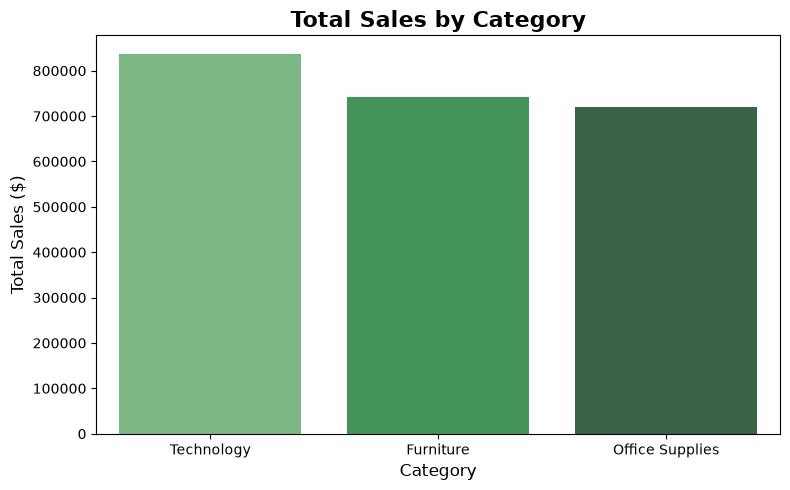

Chart 6 saved!


In [10]:
# Chart 6: Sales by Category
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Greens_d')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_sales_by_category.png', dpi=150)
plt.show()
print("Chart 6 saved!")

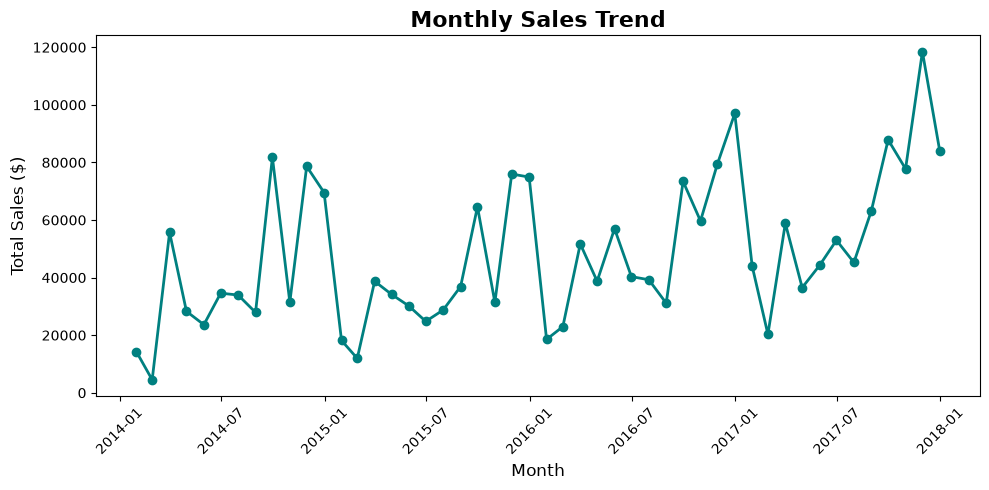

Chart 7 saved!


In [11]:
# Chart 7: Monthly Sales Trend
plt.figure(figsize=(10, 5))
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='teal')
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart7_monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart 7 saved!")

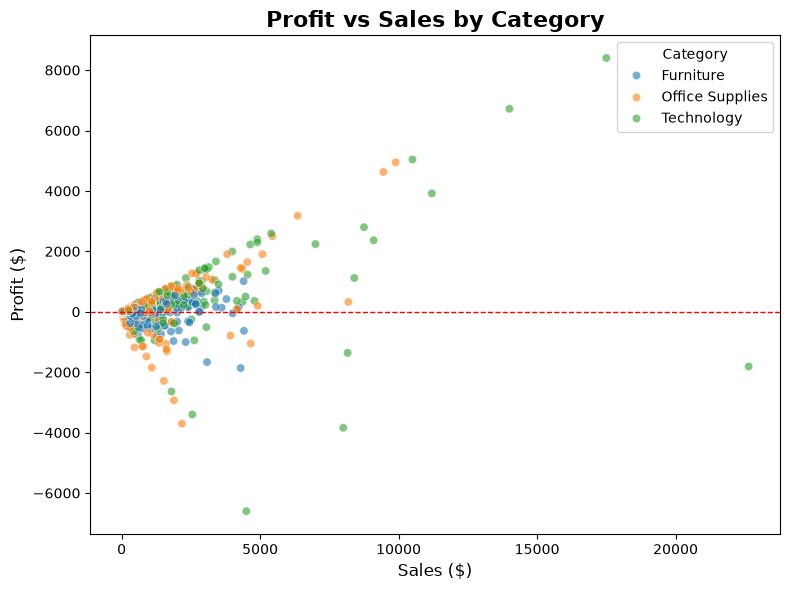

Chart 8 saved!


In [12]:
# Chart 8: Profit vs Sales scatter, colored by Category
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.6)
plt.title('Profit vs Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('chart8_profit_vs_sales.png', dpi=150)
plt.show()
print("Chart 8 saved!")

In [13]:
# Summary: Unprofitable orders by category
loss_orders = df[df['Profit'] < 0]
print(f"Total unprofitable orders: {len(loss_orders)} out of {len(df)} ({len(loss_orders)/len(df)*100:.1f}%)")
print(f"Total losses: ${loss_orders['Profit'].sum():,.2f}")
print("\nLosses by category:")
print(loss_orders.groupby('Category')['Profit'].agg(['count', 'sum']).sort_values('sum'))

Total unprofitable orders: 1871 out of 9994 (18.7%)
Total losses: $-156,131.29

Losses by category:
                 count         sum
Category                          
Furniture          714 -60936.1090
Office Supplies    886 -56615.2585
Technology         271 -38579.9182


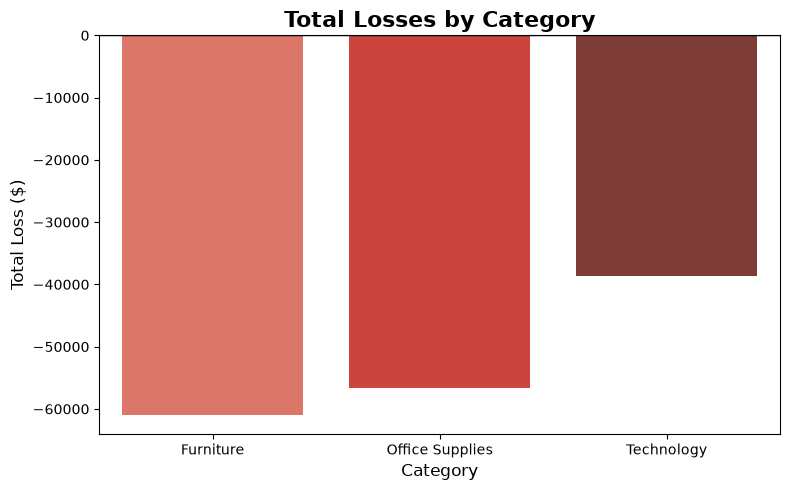

Chart 9 saved!


In [14]:
# Chart 9: Total Losses by Category
plt.figure(figsize=(8, 5))
loss_by_cat = loss_orders.groupby('Category')['Profit'].sum().sort_values()
sns.barplot(x=loss_by_cat.index, y=loss_by_cat.values, palette='Reds_d')
plt.title('Total Losses by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Loss ($)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('chart9_losses_by_category.png', dpi=150)
plt.show()
print("Chart 9 saved!")

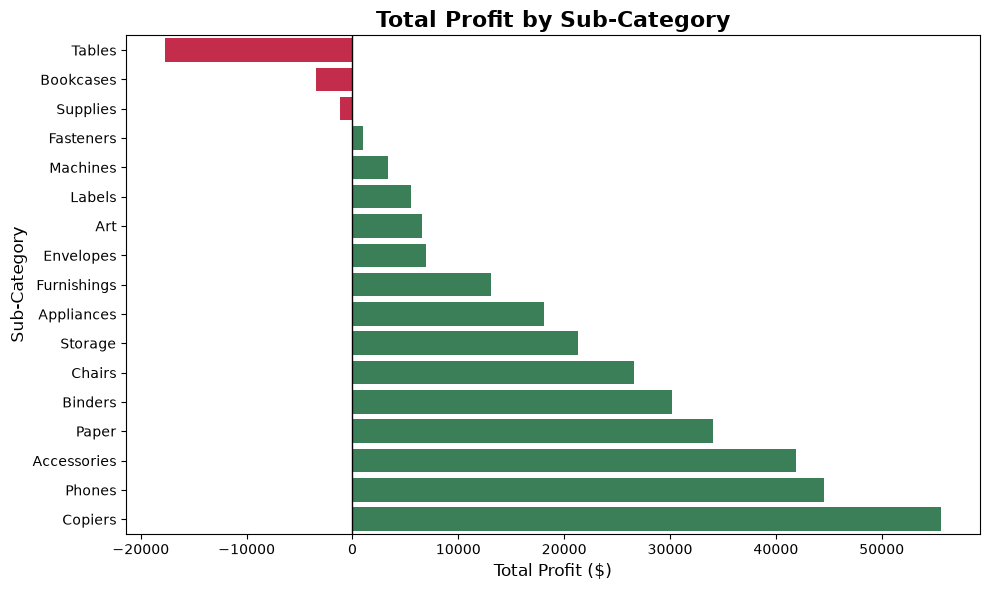

Chart 10 saved!


In [15]:
# Chart 10: Profit by Sub-Category
plt.figure(figsize=(10, 6))
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['crimson' if x < 0 else 'seagreen' for x in subcat_profit.values]
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette=colors)
plt.title('Total Profit by Sub-Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('chart10_profit_by_subcategory.png', dpi=150)
plt.show()
print("Chart 10 saved!")

## Key Insights & Conclusion

*1. Profitability vs Sales mismatch:* Furniture generates high sales (USD 742K) but the lowest profit (USD 18K) of all categories — driven almost entirely by losses in *Tables (-USD17K)*, which is the single biggest loss-maker in the entire dataset.

*2. Top profit drivers:* Copiers, Phones, and Accessories are the most profitable sub-categories, despite not being the highest in sales volume — showing profit margin matters more than revenue alone.

*3. Regional opportunity:* The West and East regions lead in sales, while the South region lags significantly (~\$392K) — a potential area for targeted growth strategies.

*4. Seasonality:* Sales show a clear yearly upward trend (2014–2017) with recurring seasonal peaks, typically toward Q4 (Nov–Dec), useful for inventory and staffing planning.

*5. Order-level risk:* 18.7% of all orders (1,871 of 9,994) are unprofitable, totaling -\$156K in losses — concentrated heavily in Furniture and Office Supplies orders.

*Business Recommendation:* Reassess pricing, discounting, or shipping costs on Tables and Bookcases specifically, as they are dragging down overall company profitability despite healthy total sales.